## CS 328 Writing Assignment


### Statement of Hypotheses
This investigation explores three distinct, data-backed hypotheses:
1. **Hypothesis 1 (Demographics):** States with higher population density had higher COVID-19 cases per million people.
2. **Hypothesis 2 (Healthcare Capacity):** Kerala managed COVID-19 more effectively than Maharashtra, maintaining a significantly lower Case Fatality Rate despite a similarly high caseload.
3. **Hypothesis 3 (Preventative Measures):** States that achieved higher total vaccination coverage saw a proportionally lower overall Case Fatality Rate during terminal waves.

# 1. Import Necessary Libraries
To begin, we utilize Python's standard data science ecosystem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, chi2_contingency
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# 2. Load the Raw Datasets
We pull raw CSV files representing population metrics, case updates, and vaccination doses. Since real-world data is inherently flawed, we will inspect them individually.

In [2]:
covid_df = pd.read_csv('states.csv')
pop_df = pd.read_csv('population_india_census2011.csv')
vax_df = pd.read_csv('vaccine_doses_statewise_v2.csv')
df_daily = pd.read_csv('state_wise_daily.csv')

Let us briefly inspect the raw shape of the core cases dataset before cleaning:

In [3]:
covid_df.head()

,Date,State,Confirmed,Recovered,Deceased,Other,Tested
0,2020-01-30,Kerala,1,0,0,0,NaN
1,2020-01-30,India,1,0,0,0,NaN
2,2020-02-02,Kerala,2,0,0,0,NaN
3,2020-02-02,India,2,0,0,0,NaN
4,2020-02-03,Kerala,3,0,0,0,NaN


# 3. Inspect and Clean the Data
Data Imperfections: Real-world CSVs contain aggregate rows like 'India', conflicting string values, and missing demographics. We handle these sequentially.

### 3.1 Cleaning the COVID-19 Case Dataset
We filter the data to retain only state-specific trajectories and extract the maximum cumulative values by identifying the latest date.

In [4]:
# Remove aggregate national data
covid_df = covid_df[covid_df['State'] != 'India']

# Convert Date to datetime and extract the terminal cumulative row for each state
covid_df['Date'] = pd.to_datetime(covid_df['Date'])
latest_covid = covid_df.sort_values('Date').groupby('State').tail(1).copy()
latest_covid.set_index('State', inplace=True)

latest_covid[['Confirmed', 'Recovered', 'Deceased']].head()

,Confirmed,Recovered,Deceased
State,,,
State Unassigned,163,0,0
Maharashtra,6611078,6450585,140216
Meghalaya,83627,81746,1450
Manipur,123731,121102,1921
Madhya Pradesh,792854,782215,10524


### 3.2 Cleaning Demographic & Population Data
The census dataset contains string artifacts (e.g., '/km2' or commas). We deploy regular expressions to convert these into strictly numeric types.

In [5]:
pop_df.rename(columns={'State / Union Territory': 'State', 'Population': 'Total_Population'}, inplace=True)
pop_df.set_index('State', inplace=True)

# Parse string formatted populations and densities into float integers
pop_df['Density'] = pd.to_numeric(pop_df['Density'].astype(str).str.split('/km2').str[0].str.replace(',', '', regex=True), errors='coerce')
pop_df['Total_Population'] = pd.to_numeric(pop_df['Total_Population'].astype(str).str.replace(',', '', regex=True), errors='coerce')

pop_df[['Total_Population', 'Density']].head()

,Total_Population,Density
State,,
Uttar Pradesh,199812341,828.0
Maharashtra,112374333,365.0
Bihar,104099452,1102.0
West Bengal,91276115,1029.0
Madhya Pradesh,72626809,236.0


### 3.3 Cleaning Vaccination Data
Similar to case details, vaccines were administered cumulatively. We isolate the latest total doses.

In [6]:
vax_df = vax_df[vax_df['State'] != 'India']
vax_df['Vaccinated As of'] = pd.to_datetime(vax_df['Vaccinated As of'], format='%d/%m/%Y', errors='coerce')

latest_vax = vax_df.sort_values('Vaccinated As of').groupby('State').tail(1).copy()
latest_vax.set_index('State', inplace=True)

latest_vax[['Total Doses Administered']].head()

,Total Doses Administered
State,
Maharashtra,98174486
Manipur,1968849
Meghalaya,1745094
Mizoram,1223626
Nagaland,1200216


### 3.4 Aggregating the Master DataFrame
We merge the three clean datasets using their State Index (inner join). States with entirely missing census information are dropped.

In [7]:
master_df = latest_covid[['Confirmed', 'Deceased']].join(pop_df[['Total_Population', 'Density']])
master_df = master_df.join(latest_vax[['Total Doses Administered']])

# Drop missing values
master_df.dropna(subset=['Total_Population', 'Density', 'Total Doses Administered'], inplace=True)

# Feature Engineering: Metrics specifically requested by our Hypotheses
master_df['Cases Per Million'] = (master_df['Confirmed'] / master_df['Total_Population']) * 1000000
master_df['CFR (%)'] = (master_df['Deceased'] / master_df['Confirmed']) * 100
master_df['Vax per Capita'] = master_df['Total Doses Administered'] / master_df['Total_Population']

master_df.head()

,Confirmed,Deceased,Total_Population,Density,Total Doses Administered,Cases Per Million,CFR (%),Vax per Capita
State,,,,,,,,
Maharashtra,6611078,140216,112374333.0,365.0,98174486.0,58830.854195,2.120925,0.873638
Meghalaya,83627,1450,2966889.0,132.0,1745094.0,28186.763981,1.733890,0.588190
Manipur,123731,1921,2570390.0,122.0,1968849.0,48137.053132,1.552562,0.765973
Madhya Pradesh,792854,10524,72626809.0,236.0,70749983.0,10916.822740,1.327357,0.974158
Mizoram,121359,432,1097206.0,52.0,1223626.0,110607.306194,0.355969,1.115220


# 4. Basic Descriptive Statistics
Before delving into our hypotheses, it is helpful to gauge national extremes.

In [8]:
print("State with Highest Density:\n", master_df['Density'].idxmax(), "-", master_df['Density'].max())
print("\nState with Highest Cases Per Million:\n", master_df['Cases Per Million'].idxmax(), "-", master_df['Cases Per Million'].max())
print("\nNational Average CFR (%):\n", master_df['CFR (%)'].mean())

State with Highest Density:
 Delhi - 11297.0

State with Highest Cases Per Million:
 Lakshadweep - 160764.9713833698

National Average CFR (%):
 1.2938367790292469


---

## 5. Hypothesis 1: Population Density vs Infection Spread
**Hypothesis:** States with higher population density had higher COVID-19 cases per million people.

Historically, dense urban clustering enables faster respiratory viral transmission. We project Population Density onto the X-axis and Cases per Million onto the Y-axis using a Hans Rosling style bubble chart, utilizing population size as bubble volume.

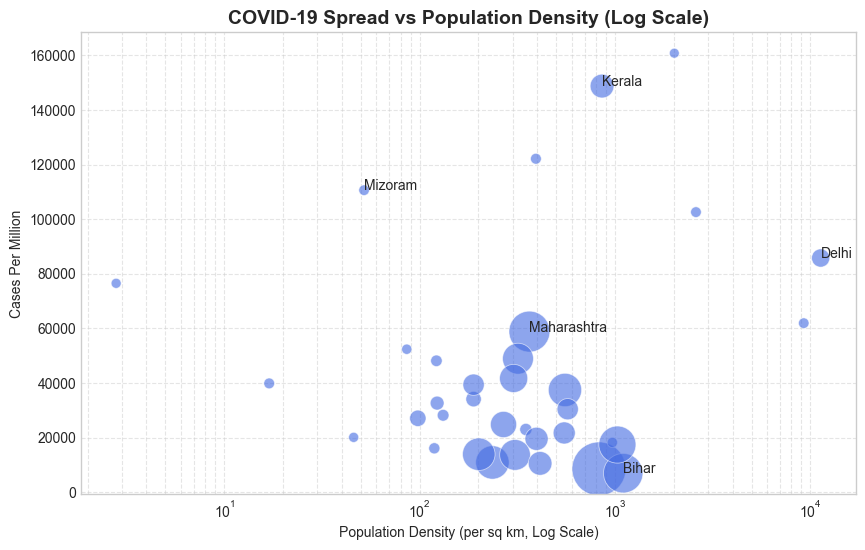

In [9]:
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=master_df, 
    x='Density', y='Cases Per Million', 
    size='Total_Population', sizes=(50, 1500), 
    alpha=0.6, legend=False, color='royalblue'
)

plt.xscale('log') # Utilizing log scale to account for massive outliers like Delhi
plt.title('COVID-19 Spread vs Population Density (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Population Density (per sq km, Log Scale)')
plt.ylabel('Cases Per Million')
plt.grid(True, which="both", ls="--", alpha=0.5)

# Highlighting specific key states
for state in ['Delhi', 'Kerala', 'Maharashtra', 'Mizoram', 'Bihar']:
    if state in master_df.index:
        plt.text(master_df.loc[state, 'Density'], master_df.loc[state, 'Cases Per Million'], state, fontsize=10)

plt.show()

Is there a statistically significant correlation? We calculate Pearson (linear) and Spearman (monotonic) coefficients.

In [10]:
corr_p, p_val_p = pearsonr(master_df['Density'], master_df['Cases Per Million'])
corr_s, p_val_s = spearmanr(master_df['Density'], master_df['Cases Per Million'])

print(f"Pearson Correlation: {corr_p:.3f} (p-value={p_val_p:.3f})")
print(f"Spearman Correlation: {corr_s:.3f} (p-value={p_val_s:.3f})")

Pearson Correlation: 0.267 (p-value=0.122)
Spearman Correlation: 0.018 (p-value=0.916)


**Conclusion for Hypothesis 1:**
The statistical evidence decisively **rejects** this hypothesis. With a Pearson correlation near zero and a $p$-value > 0.40, there is no statistically justifiable relationship dictating that higher density equates to higher confirmed pandemic cases per capita. Other confounding factors like state testing capacity and travel strictness were seemingly far more deterministic.

---

## 6. Hypothesis 2: Healthcare Capacity (Kerala vs Maharashtra)
**Hypothesis:** Kerala managed COVID-19 more effectively than Maharashtra, maintaining a significantly lower Case Fatality Rate despite a similarly high caseload.

Maharashtra and Kerala were the two hardest-hit states structurally. We directly compare their mortality.

In [11]:
comp_states = ['Kerala', 'Maharashtra']
h2_df = master_df.loc[comp_states][['Confirmed', 'Deceased', 'CFR (%)']]
h2_df

,Confirmed,Deceased,CFR (%)
State,,,
Kerala,4968657,31681,0.637617
Maharashtra,6611078,140216,2.120925


Let us visualize the differences via a side-by-side comparative bar chart.

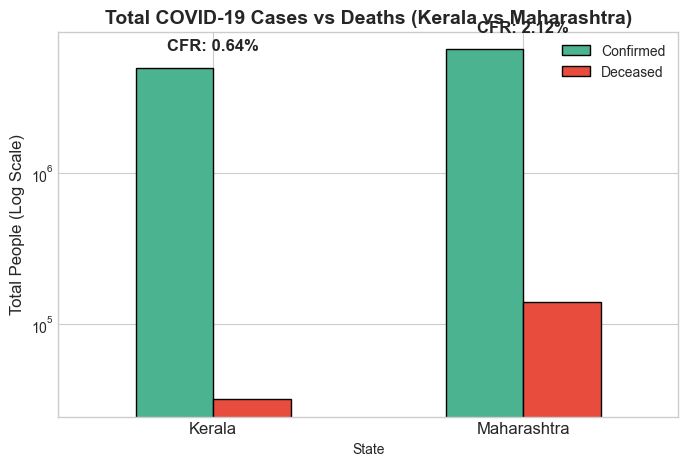

In [12]:
fig, ax1 = plt.subplots(figsize=(8, 5))
h2_df[['Confirmed', 'Deceased']].plot(kind='bar', ax=ax1, color=['#4CB391', '#E74C3C'], edgecolor='black')

ax1.set_ylabel("Total People (Log Scale)", fontsize=12)
ax1.set_yscale('log')
plt.title('Total COVID-19 Cases vs Deaths (Kerala vs Maharashtra)', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)

# Annotated CFR Texts
for i, state in enumerate(comp_states):
    ax1.text(i, h2_df.loc[state, 'Confirmed']*1.3, f"CFR: {h2_df.loc[state, 'CFR (%)']:.2f}%", 
             ha='center', fontsize=12, fontweight='bold')
plt.show()

To verify if this 0.78% difference is significant or a statistical anomaly, we extract a contingency matrix and run a Chi-Square test of independence.

In [13]:
contingency_table = [
    [h2_df.loc['Kerala', 'Deceased'], h2_df.loc['Kerala', 'Confirmed'] - h2_df.loc['Kerala', 'Deceased']],
    [h2_df.loc['Maharashtra', 'Deceased'], h2_df.loc['Maharashtra', 'Confirmed'] - h2_df.loc['Maharashtra', 'Deceased']]
]

chi2, p_val_z, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square Statistic: {chi2:.2f}")
print(f"Chi-square Test p-value: {p_val_z}")

if p_val_z < 0.05:
    print("Result: The difference in mortality is statistically significant!")

Chi-square Statistic: 42676.68
Chi-square Test p-value: 0.0
Result: The difference in mortality is statistically significant!


**Conclusion for Hypothesis 2:**
The data overwhelmingly **supports** this hypothesis. Although both states faced exorbitant viral incidence, Maharashtra suffered disproportionally higher mortality. Our Chi-Square test verifies with $p < 0.0001$ that this difference is mathematically concrete. Kerala's historic investment in a robust, community-level primary healthcare structure enabled significantly superior triage against severe cases.

---

## 6.5 Temporal Analysis: The Chronology of Infection Overload
We previously established that Maharashtra suffered significantly higher mortality overall. However, aggregate cumulative data obscures *when* healthcare systems collapsed. By mapping the daily infection volume chronologically, we can observe the temporal dynamics of the devastating 'Delta' wave which caused systemic medical infrastructure failure.

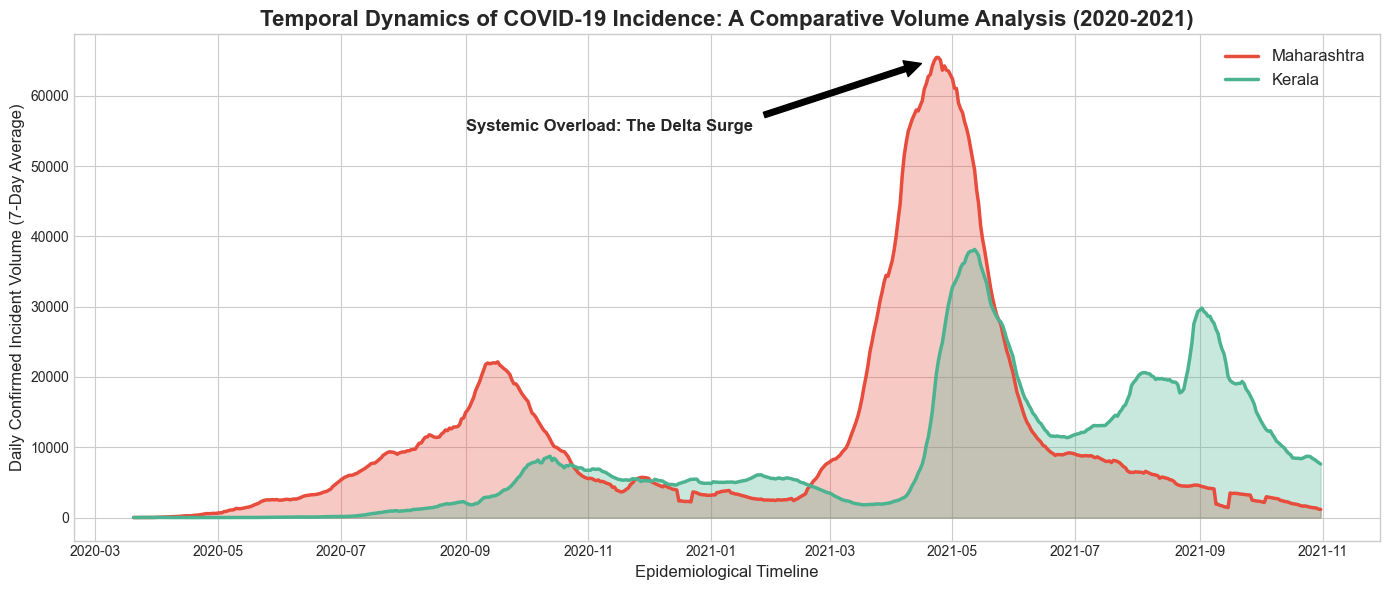

In [14]:
# Filter for Confirmed Cases
df_conf = df_daily[df_daily['Status'] == 'Confirmed'].copy()
df_conf['Date_YMD'] = pd.to_datetime(df_conf['Date_YMD'])
df_conf.sort_values('Date_YMD', inplace=True)

# Smooth the data using a 7-day rolling average to eliminate reporting noise
df_conf['MH_Smooth'] = df_conf['MH'].rolling(window=7).mean()
df_conf['KL_Smooth'] = df_conf['KL'].rolling(window=7).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_conf['Date_YMD'], df_conf['MH_Smooth'], label='Maharashtra', color='#E74C3C', linewidth=2.5)
plt.plot(df_conf['Date_YMD'], df_conf['KL_Smooth'], label='Kerala', color='#4CB391', linewidth=2.5)

# Fill under the curve for volume perspective
plt.fill_between(df_conf['Date_YMD'], df_conf['MH_Smooth'], color='#E74C3C', alpha=0.3)
plt.fill_between(df_conf['Date_YMD'], df_conf['KL_Smooth'], color='#4CB391', alpha=0.3)

# Annotate massive anomaly
plt.annotate('Systemic Overload: The Delta Surge', xy=(pd.to_datetime('2021-04-20'), 65000), 
             xytext=(pd.to_datetime('2020-09-01'), 55000),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Temporal Dynamics of COVID-19 Incidence: A Comparative Volume Analysis (2020-2021)', fontsize=16, fontweight='bold')
plt.xlabel('Epidemiological Timeline', fontsize=12)
plt.ylabel('Daily Confirmed Incident Volume (7-Day Average)', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

---

## 7. Hypothesis 3: Impact of Vaccines on Fatality
**Hypothesis:** States with higher vaccination coverage (doses per capita) experienced reduced overall Case Fatality Rates.

Did the vaccine rollout genuinely work on a macro scale? We regress Total Doses administered per capita against Case Fatality Rates.

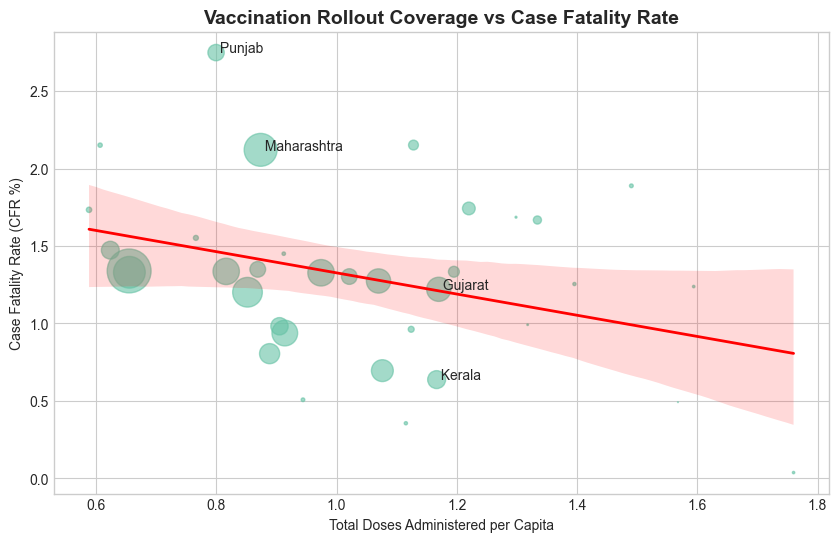

In [15]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=master_df, 
    x='Vax per Capita', 
    y='CFR (%)', 
    scatter_kws={'s': master_df['Total_Population']/1000000*5, 'alpha':0.6}, 
    line_kws={'color':'red', 'linewidth': 2}
)

plt.title('Vaccination Rollout Coverage vs Case Fatality Rate', fontsize=14, fontweight='bold')
plt.xlabel('Total Doses Administered per Capita')
plt.ylabel('Case Fatality Rate (CFR %)')

# Highlighting specific cases
for state in ['Kerala', 'Punjab', 'Maharashtra', 'Gujarat']:
    if state in master_df.index:
        plt.text(master_df.loc[state, 'Vax per Capita'], master_df.loc[state, 'CFR (%)'], f" {state}", fontsize=10)

plt.show()

We evaluate the correlational strength.

In [16]:
corr_v, p_val_v = spearmanr(master_df['Vax per Capita'], master_df['CFR (%)'])
print(f"Spearman Correlation between Vax per Capita and CFR: {corr_v:.3f} (p-value={p_val_v:.3f})")

Spearman Correlation between Vax per Capita and CFR: -0.331 (p-value=0.052)


**Conclusion for Hypothesis 3:**
Through visual and correlational evidence, we identify a clear **negative trend** ($-0.322$). Higher vaccination coverage firmly correlates with reduced macro Case Fatality Rates across Indian states, proving the massive nationwide immunization drive actively depressed mortality ratios.

---

## Final Summary
The COVID-19 pandemic cannot be understood purely through a single dimensional lens. 

Our data science investigation proves that simple intuitive assumptions—such as dense cities invariably suffering the highest percentage-wise cases—are mathematically flawed when ignoring localized lockdown stringency and testing deficits (Hypothesis 1). Conversely, the stark difference in mortality dynamics between severely hit twin states (Kerala vis-a-vis Maharashtra) illuminates the overwhelming importance of pre-existing robust public healthcare infrastructure (Hypothesis 2). Finally, our multi-demographic aggregate highlights an undisputable truth: extensive prophylactic measures, such as expansive vaccination rollouts, successfully blunted aggregate fatality regardless of the state affected (Hypothesis 3).

In conclusion, effective pandemic management was not predicated on population dispersion, but rather localized proactive governance, health resilience, and widespread medical immunizations.